<class 'pandas.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      1900 non-null   str  
 1   HomeTeam  1900 non-null   str  
 2   AwayTeam  1900 non-null   str  
 3   FTHG      1900 non-null   int64
 4   FTAG      1900 non-null   int64
 5   FTR       1900 non-null   str  
 6   HS        1900 non-null   int64
 7   AS        1900 non-null   int64
 8   HST       1900 non-null   int64
 9   AST       1900 non-null   int64
dtypes: int64(6), str(4)
memory usage: 148.6 KB
None
              FTHG         FTAG           HS           AS          HST  \
count  1900.000000  1900.000000  1900.000000  1900.000000  1900.000000   
mean      1.597368     1.329474    14.158947    11.710526     4.872105   
std       1.318038     1.204203     5.657133     5.171355     2.567870   
min       0.000000     0.000000     1.000000     1.000000     0.000000   
25%       1.000000     0.000000    10

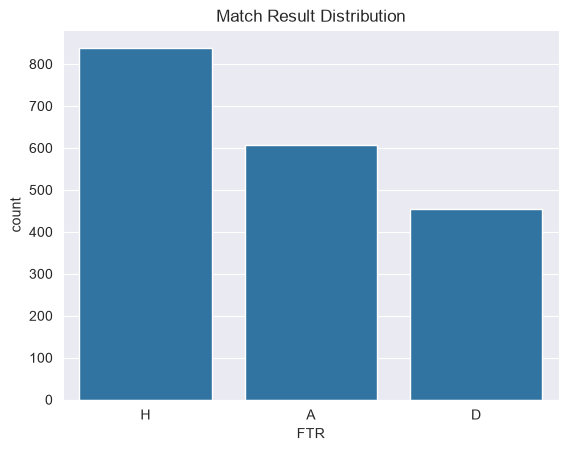

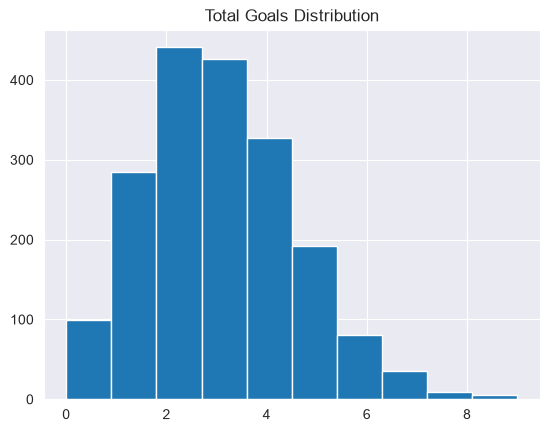

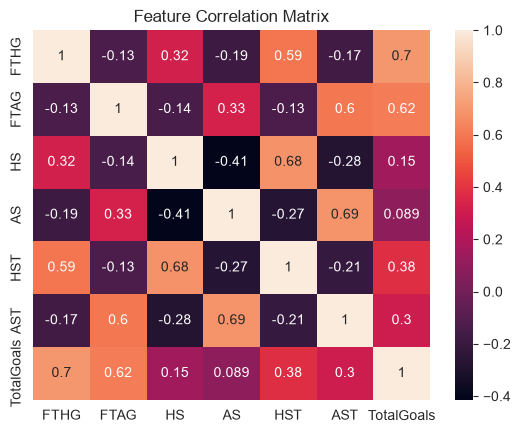

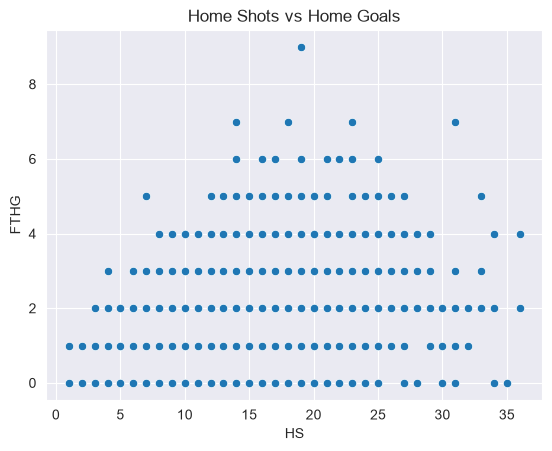

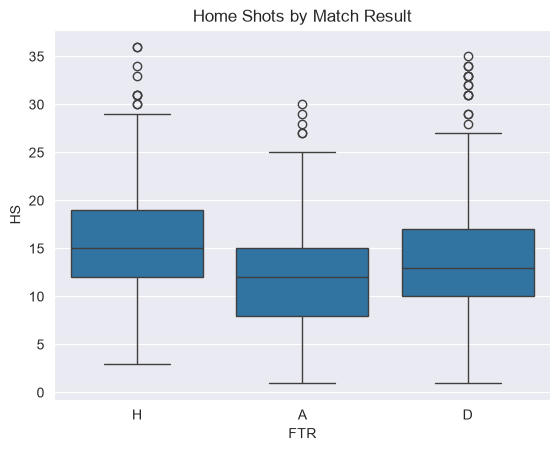

HomeTeam
Man City            2.705263
Liverpool           2.315789
Arsenal             2.231579
Newcastle           1.968421
Aston Villa         1.852632
Tottenham           1.789474
Chelsea             1.705263
Man United          1.694737
Brentford           1.673684
Fulham              1.565789
Brighton            1.536842
West Ham            1.473684
Luton               1.473684
Crystal Palace      1.347368
Nott'm Forest       1.315789
Sunderland          1.315789
Bournemouth         1.302632
Leeds               1.298246
Leicester           1.263158
Everton             1.231579
Wolves              1.168421
Sheffield United    1.000000
Burnley             0.964912
Southampton         0.964912
Watford             0.894737
Ipswich             0.736842
Norwich             0.631579
Name: FTHG, dtype: float64
AwayTeam
Liverpool           1.936842
Man City            1.905263
Arsenal             1.768421
Tottenham           1.631579
Chelsea             1.589474
Brighton            1.48421

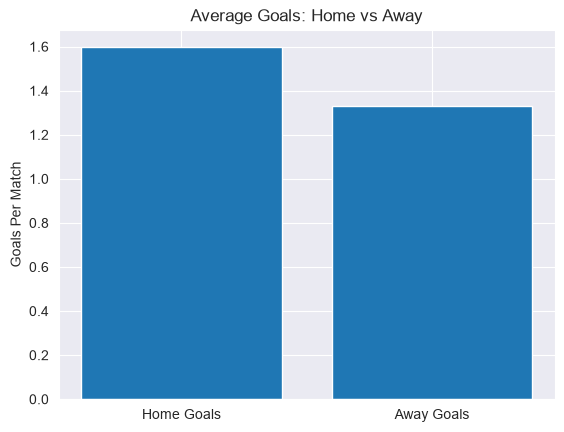

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Data reading
df = pd.read_csv("../data/processed/epl_cleaned.csv")

#brief insights
print(df.info())
print(df.describe())

#Bar plot of Match result distribution
sns.countplot(x="FTR", data=df)
plt.title("Match Result Distribution")
plt.show()

#Goal distribution
df["TotalGoals"] = df["FTHG"] + df["FTAG"]
df["TotalGoals"].hist(bins=10)
plt.title("Total Goals Distribution")
plt.show()

#Correlation Matrix
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

#Shots VS Goals
sns.scatterplot(x="HS", y="FTHG", data=df)
plt.title("Home Shots vs Home Goals")
plt.show()

#boxplot
sns.boxplot(x="FTR", y="HS", data=df)
plt.title("Home Shots by Match Result")
plt.show()

#Team performance at home
team_goals_home = (
    df.groupby("HomeTeam")["FTHG"]
    .mean()
    .sort_values(ascending=False)
)
print(team_goals_home)

#Team performance away
team_goals_away = (
    df.groupby("AwayTeam")["FTAG"]
    .mean()
    .sort_values(ascending=False)
)
print(team_goals_away)

#home vs away win rate
home_win_rate = (df["FTR"] == "H").mean()
print(home_win_rate)
away_win_rate = (df["FTR"] == "A").mean()
print(away_win_rate)

df["GoalDifference"] = df["FTHG"] - df["FTAG"]
home_advantage = df["GoalDifference"].mean()
print(home_advantage)

#visualise home advantage
goal_means = [
    df["FTHG"].mean(),
    df["FTAG"].mean()
]

labels = ["Home Goals", "Away Goals"]

plt.bar(labels, goal_means)

plt.title("Average Goals: Home vs Away")

plt.ylabel("Goals Per Match")

plt.show()
